In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

## 1. Data Collection

In [63]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start , end)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-06-03,22.291458,22.371135,22.184462,22.261864,114019600
2016-06-06,22.453087,23.195225,22.207227,22.307391,93170000
2016-06-07,22.544140,22.735366,22.528204,22.594223,89638000
2016-06-08,22.523657,22.664799,22.464467,22.541867,83392400
2016-06-09,22.685289,22.762689,22.414386,22.423492,106405600


## 2. Data Exploration adn Visulaization

In [64]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,124.312295,125.544650,122.955295,124.190069,9.633615e+07
std,76.910612,77.638552,76.100897,76.823784,5.476533e+07
min,20.952875,21.182802,20.829944,21.148654,1.791060e+07
25%,44.997887,45.293132,44.663311,45.023879,5.699800e+07
50%,129.889252,131.183540,128.264143,129.918453,8.457360e+07
75%,180.588593,182.093512,178.855462,180.121114,1.169989e+08
max,315.200012,315.450012,309.570007,311.779999,4.479400e+08


In [65]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2513 entries, 2016-06-03 to 2026-06-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   2513 non-null   float64
 1   (High, AAPL)    2513 non-null   float64
 2   (Low, AAPL)     2513 non-null   float64
 3   (Open, AAPL)    2513 non-null   float64
 4   (Volume, AAPL)  2513 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.8 KB


Text(0, 0.5, 'Close Price')

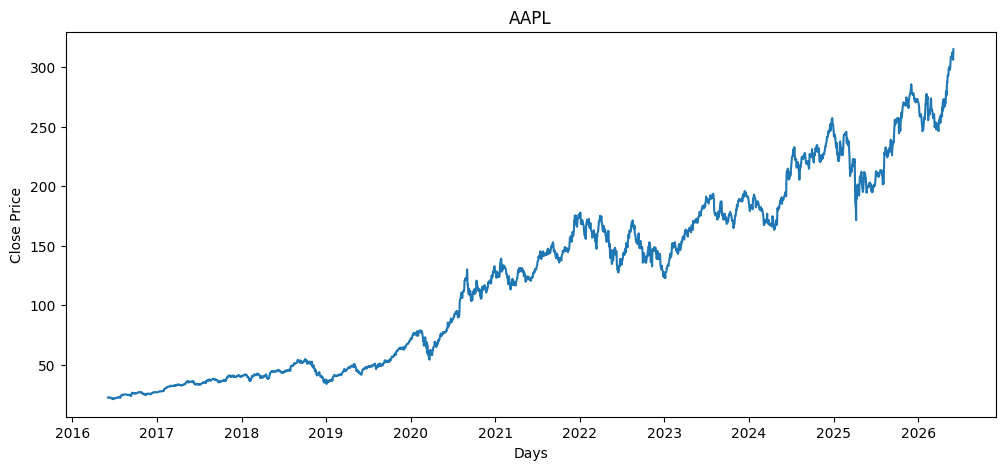

In [66]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

## 3. Feature Engineering

### 100 Days Moving Avg

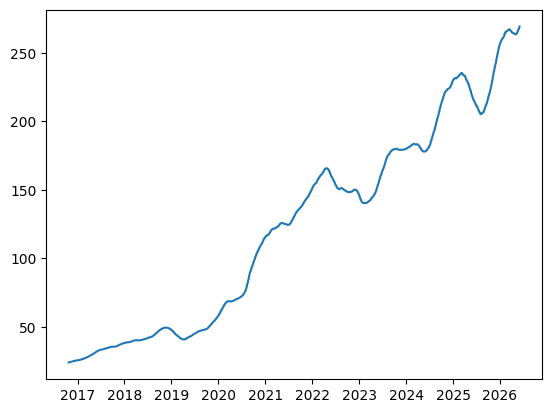

In [67]:
df['MA_100'] = df.Close.rolling(100).mean()
plt.plot(df['MA_100'])

Text(0, 0.5, 'Price')

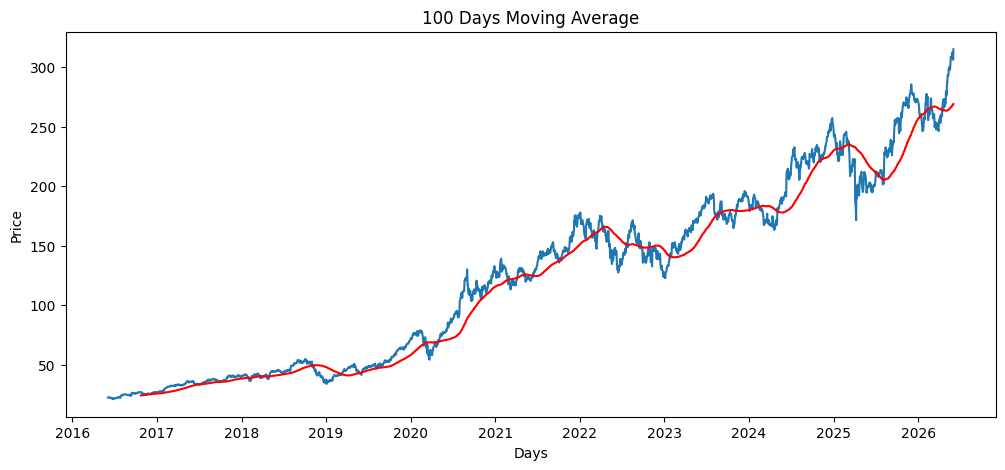

In [68]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'] , 'r')
plt.title('100 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')


### 200 Days Moving Avg

In [75]:
df['MA_200'] = df.Close.rolling(200).mean()

Text(0, 0.5, 'Price')

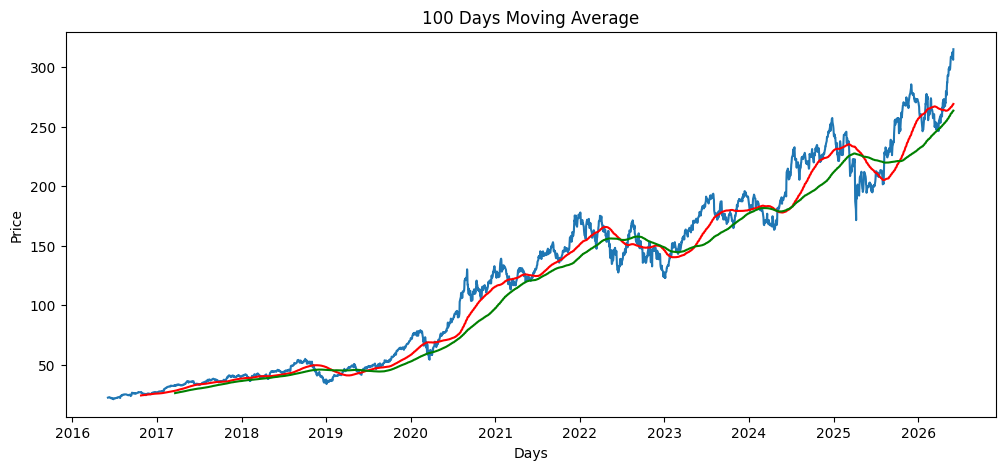

In [76]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'] , 'r')
plt.plot(df['MA_200'] , 'g')
plt.title('200 Days Moving Average')
plt.xlabel('Days')
plt.ylabel('Price')


### Calculate % changed in each trading session

In [84]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']].shape

(2513, 2)

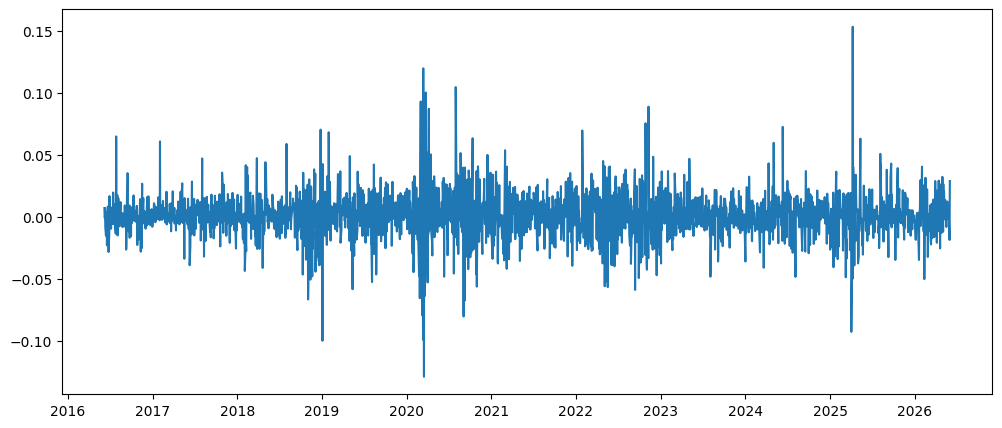

In [86]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'])

In [87]:
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))])

data_training.shape, data_testing.shape

((1759, 1), (754, 1))

In [88]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [91]:
data_training_array = scaler.fit_transform(data_training)
data_training_array.shape

(1759, 1)

## 5.Sequence Creation

In [92]:
x_train = []
y_train = []
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train)
x_train.shape, y_train.shape

((1659, 100, 1), (1659,))

## 6. Model Building

In [93]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [96]:
model = Sequential()
model.add(Input(shape=(100,1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

## 7.Model Training

In [97]:
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(x_train,y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0186
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step - loss: 6.3696e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - loss: 6.4509e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - loss: 5.8269e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 182ms/step - loss: 6.1021e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 5.6816e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - loss: 5.0223e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - loss: 5.2028e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - loss: 5.3235e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 180ms/step - loss: 5.2273e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 233ms/step - loss: 4.1243e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 17s 151ms/step - loss: 4.7054e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 12s 176ms/step - loss: 4.2574e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - loss: 3.9349

In [98]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [99]:
model.save('stock_prediction_model.keras')

## 8.Preparing Test Data

In [101]:
past_100_days = data_training.tail(100)
past_100_days

Ticker,AAPL
Date,
2023-01-05,122.933548
2023-01-06,127.456787
2023-01-09,127.977936
2023-01-10,128.548279
2023-01-11,131.262222
...,...
2023-05-23,169.188110
2023-05-24,169.464264
2023-05-25,170.598358


In [103]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

Ticker,AAPL
0,122.933548
1,127.456787
2,127.977936
3,128.548279
4,131.262222
...,...
849,310.850006
850,312.510010
851,312.059998
852,306.309998


In [104]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.        ],
       [0.02352589],
       [0.02623644],
       [0.02920286],
       [0.04331839],
       [0.04290928],
       [0.04981336],
       [0.05584826],
       [0.05211488],
       [0.05242177],
       [0.06571892],
       [0.0822893 ],
       [0.0895517 ],
       [0.08612498],
       [0.09686513],
       [0.10694039],
       [0.09195528],
       [0.09855286],
       [0.10438308],
       [0.13194941],
       [0.15076988],
       [0.13660332],
       [0.15153692],
       [0.13757503],
       [0.13220503],
       [0.13410022],
       [0.14864724],
       [0.14531758],
       [0.15622773],
       [0.14793004],
       [0.14198839],
       [0.12114132],
       [0.12334379],
       [0.12585356],
       [0.11207524],
       [0.11827283],
       [0.11566053],
       [0.1049041 ],
       [0.10797742],
       [0.13420275],
       [0.14854463],
       [0.13712243],
       [0.14362747],
       [0.13194893],
       [0.12124361],
       [0.13133427],
       [0.14219323],
       [0.144

In [105]:
input_data.shape

(854, 1)

In [106]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

In [107]:
x_test, y_test = np.array(x_test), np.array(y_test)
x_test.shape, y_test.shape

((754, 100, 1), (754,))

## 9. Making Prediction

In [108]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step


In [109]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1,1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1,1)).flatten()

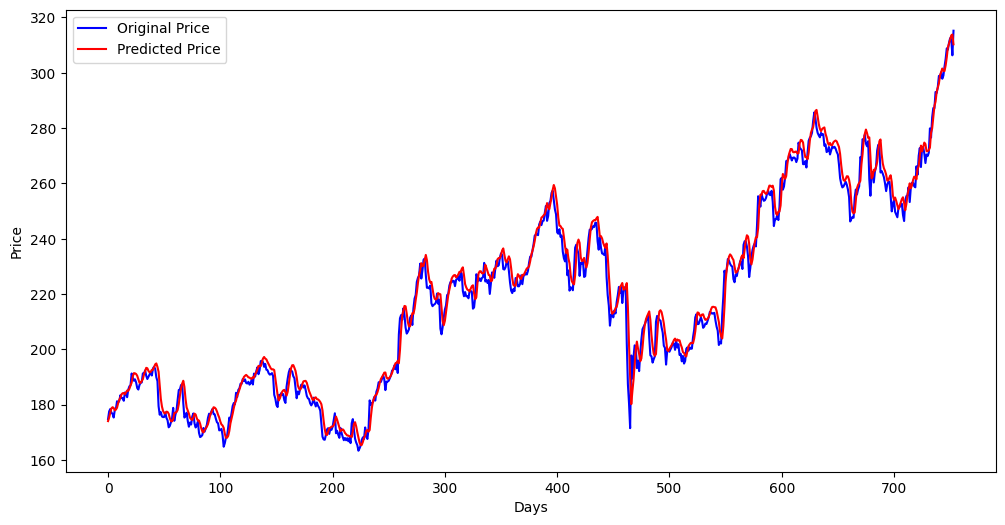

In [113]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted,'r',label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

## 10.Model Evaluation

In [118]:
from sklearn.metrics import mean_squared_error, r2_score

In [115]:
mse = mean_squared_error(y_test,y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 20.229212535149045


In [116]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.497689688623376


In [119]:
r2 = r2_score(y_test, y_predicted)
print(f"R-squared: {r2}")

R-squared: 0.9836314091874823
